# Lesson 11: Nonparametric, Permutation, and Bootstrap Methods

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Choose rank tests for ordinal or rank-based estimands
2. Construct a permutation test aligned with the null hypothesis
3. Use bootstrap confidence intervals while respecting the sampling unit
4. Recognize exchangeability and resampling limitations


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 11.1 Three families, three ideas

- **Rank tests** replace raw values with order information and target rank/distribution contrasts.
- **Permutation tests** generate a null distribution by shuffling labels in a way justified by the null.
- **Bootstrap intervals** approximate sampling uncertainty by resampling observational units.

None of these methods repairs biased sampling, dependence, confounding, or the wrong unit of analysis.


In [2]:
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
clinton = anes.loc[anes["expected_vote"] == "Clinton", "income_code"].to_numpy()
dole = anes.loc[anes["expected_vote"] == "Dole", "income_code"].to_numpy()
observed_diff = dole.mean()-clinton.mean()

def mean_difference(x, y, axis=0):
    return np.mean(y, axis=axis)-np.mean(x, axis=axis)

perm = stats.permutation_test((clinton, dole), mean_difference,
                              permutation_type="independent", alternative="two-sided",
                              n_resamples=9999, random_state=20260920)
mw = stats.mannwhitneyu(dole, clinton, alternative="two-sided")
pd.Series({"observed income-code difference (Dole-Clinton)": observed_diff,
           "permutation p": perm.pvalue, "Mann-Whitney U": mw.statistic,
           "Mann-Whitney p": mw.pvalue})


observed income-code difference (Dole-Clinton)    2.3048e+00
permutation p                                     2.0000e-04
Mann-Whitney U                                    1.3210e+05
Mann-Whitney p                                    7.3009e-09
dtype: float64

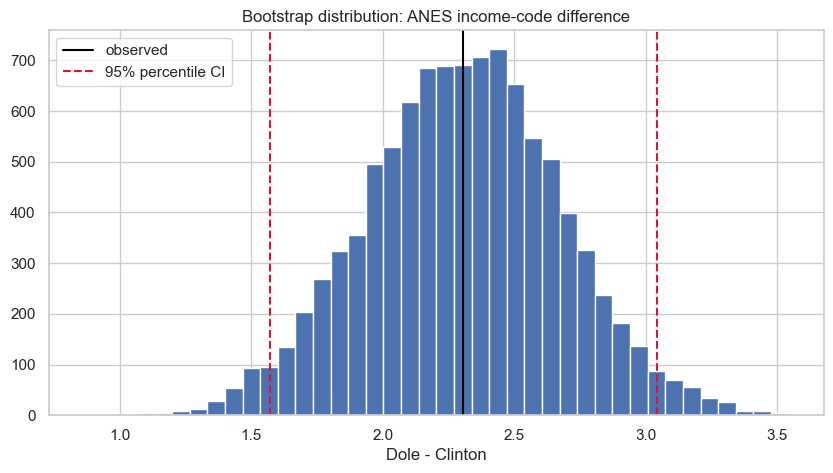

95% bootstrap percentile CI: [1.57, 3.04]


In [3]:
bootstrap_diffs = np.empty(10000)
for i in range(len(bootstrap_diffs)):
    clinton_star = rng.choice(clinton, size=len(clinton), replace=True)
    dole_star = rng.choice(dole, size=len(dole), replace=True)
    bootstrap_diffs[i] = dole_star.mean()-clinton_star.mean()
percentile_ci = np.quantile(bootstrap_diffs, [.025, .975])

fig, ax = plt.subplots()
ax.hist(bootstrap_diffs, bins=40, edgecolor="white")
ax.axvline(observed_diff, color="black", label="observed")
ax.axvline(percentile_ci[0], color="crimson", linestyle="--")
ax.axvline(percentile_ci[1], color="crimson", linestyle="--", label="95% percentile CI")
ax.set(title="Bootstrap distribution: ANES income-code difference", xlabel="Dole - Clinton")
ax.legend(); plt.show()
print(f"95% bootstrap percentile CI: [{percentile_ci[0]:.2f}, {percentile_ci[1]:.2f}]")


## 11.2 Exchangeability is the key permutation assumption

Under the sharp null in a randomized experiment, treatment labels can be shuffled according to the
randomization scheme. In observational data, unrestricted shuffling assumes groups are exchangeable.
Paired data require sign-flips or within-pair swaps; clustered experiments require cluster-level
permutations.


## Worked example and interpretation

### Different procedures answer different questions

The ANES example compares *income-category codes* between expected-vote groups. The Dole minus Clinton mean-code difference is 2.305. A permutation test repeatedly reallocates complete respondent labels across the two independent groups and obtains p = 0.0002 for a mean-difference statistic under exchangeability. Mann–Whitney compares ranks and also finds separation (p about 7.3 × 10⁻⁹), but its estimand is not the same as a difference of means or automatically a difference of medians. The permutation result depends on which labels are exchangeable under the null; it would be invalid to shuffle individual rows when observations are paired or clustered.

### Bootstrap uncertainty

The notebook resamples respondents **within each group** 10,000 times and recalculates the mean-code difference. The resulting percentile 95% interval is 1.57 to 3.04 category-code units. It quantifies uncertainty for this estimator under the empirical-resampling assumptions; it is not a null test. Because `income_code` is an ordered category, the numerical difference does not mean a currency amount. The simple percentile interval is introductory and can perform poorly with skew, small samples, or difficult dependence structures.

## Practice and solution

**Practice.** You have 10 measurements from each of 20 patients. What should a simple bootstrap resample?

<details><summary>Solution</summary>

If patients are the independent sampling units, resample patients (clusters), carrying all their
measurements together. Resampling 200 rows independently creates pseudo-replication and usually
understates uncertainty.
</details>

## Key takeaways

- Resample or permute the true independent unit.
- Use a statistic that directly represents the estimand.
- Computational methods still require design assumptions and transparent reporting.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
